# NOVI PODATOCI

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import glob

In [2]:
root = r"D:\EMTEQ\novi"
subjects = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

In [3]:
subjects

['AleksandraK',
 'AnaI',
 'AndrejCh',
 'AndrejJ',
 'AngelaK',
 'AngelaN',
 'BojanD',
 'BorjanP',
 'DavidN',
 'ElenaA',
 'HristijanD',
 'HristijanT',
 'IrinaP',
 'IvaI',
 'IvanP',
 'KristinaK',
 'LeoJ',
 'MarijaB',
 'MartinD',
 'MatrinI',
 'MihaelaD',
 'MilaP',
 'MonikaS',
 'PavelT',
 'PetarP',
 'RezeartaLj',
 'RistoK',
 'Sandra',
 'SandraM',
 'SandraSh',
 'SaraI',
 'SaraSh',
 'SlavicaSh',
 'StefanI',
 'StefanijaK',
 'StefanIl',
 'StojanV',
 'Teodora',
 'TeodoraD',
 'TeodorS',
 'TomiN',
 'VladimirK']

In [4]:
subject_csv = {}

for s in subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "*_eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        subject_csv[s] = csvs[0]
    else:
        subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(subject_csv))

 NO eating_processed for BorjanP
 NO eating_processed for HristijanT
 NO eating_processed for PetarP
Total subjects with eating_processed: 39


In [5]:
#fiksni lujge birame 
train_subjects = [
    "Ristok", "StojanV", "AndrejJ", "IvaI", "IrinaP",
    "TeodoraD", "SaraSh", "StefanI", "StefanijaK",
    "RezeartaLj", "SandraSh", "PavelT", "IvanP",
    "AngelaK", "HristijanD","SlavicaSh","MonikaS","SandraM",
    "TeodorS","SaraI","MilaP","MartinD","VladimirK","StefanIl","AndrejCh"
]

val_subjects = [
    "AleksandraK", "TomiN", "KristinaK",
    "MihaelaD", "AngelaN", "BojanD"
]

test_subjects = [
    "ElenaA", "LeoJ", "MarijaB",
    "MatrinI", "AnaI", "DavidN"
]

print("TRAIN:", len(train_subjects), train_subjects)
print("VAL:",   len(val_subjects), val_subjects)
print("TEST:",  len(test_subjects), test_subjects)


TRAIN: 25 ['Ristok', 'StojanV', 'AndrejJ', 'IvaI', 'IrinaP', 'TeodoraD', 'SaraSh', 'StefanI', 'StefanijaK', 'RezeartaLj', 'SandraSh', 'PavelT', 'IvanP', 'AngelaK', 'HristijanD', 'SlavicaSh', 'MonikaS', 'SandraM', 'TeodorS', 'SaraI', 'MilaP', 'MartinD', 'VladimirK', 'StefanIl', 'AndrejCh']
VAL: 6 ['AleksandraK', 'TomiN', 'KristinaK', 'MihaelaD', 'AngelaN', 'BojanD']
TEST: 6 ['ElenaA', 'LeoJ', 'MarijaB', 'MatrinI', 'AnaI', 'DavidN']


In [6]:
subject_csv = {}

for s in subjects:
    subj_dir = os.path.join(root, s)
    csvs = glob.glob(os.path.join(subj_dir, "*_eating_processed.csv"))

    if len(csvs) == 0:
        print(f" NO eating_processed for {s}")
    elif len(csvs) > 1:
        print(f" MORE than one for {s}, using first")
        subject_csv[s] = csvs[0]
    else:
        subject_csv[s] = csvs[0]

print("Total subjects with eating_processed:", len(subject_csv))

 NO eating_processed for BorjanP
 NO eating_processed for HristijanT
 NO eating_processed for PetarP
Total subjects with eating_processed: 39


In [7]:
def load_subject_df(subject):
    csv_path = subject_csv[subject]
    df = pd.read_csv(csv_path)
    df["subject"] = subject
    return df

In [8]:
train_dfs = [load_subject_df(s) for s in train_subjects if s in subject_csv]
val_dfs   = [load_subject_df(s) for s in val_subjects   if s in subject_csv]
test_dfs  = [load_subject_df(s) for s in test_subjects  if s in subject_csv]

print(len(train_dfs), len(val_dfs), len(test_dfs))


24 6 6


In [9]:
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(764481, 24) (186001, 24) (174005, 24)
24 6 6


In [10]:
cols_to_drop = [
    "Accelerometer Z",
    "Gyroscope Z",
    "Rotation Vector Z",
    "Rotation Vector W",
    "Magnetometer X",
    "Magnetometer Y",
    "Magnetometer Z",
    "Pressure",
    "Software Timestamp",   
    "Hardware Timestamp",   
]

train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
val_df   = val_df.drop(columns=cols_to_drop, errors="ignore")
test_df  = test_df.drop(columns=cols_to_drop, errors="ignore")


In [11]:
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["subject"].nunique(),
      val_df["subject"].nunique(),
      test_df["subject"].nunique())

(764481, 14) (186001, 14) (174005, 14)
24 6 6


In [12]:
def make_windows_from_df(df, feature_cols, label_col="Annotations", subject_col="subject",
                         time_col="Software Timestamp",
                         window_size=150, step_size=25, label_mode="majority"):
    X_list, y_list = [], []

    for sid, g in df.groupby(subject_col):
        if time_col in g.columns:
            g = g.sort_values(time_col)

        X = g[feature_cols].to_numpy(dtype="float32")
        y = g[label_col].to_numpy(dtype="int32")

        n = len(g)
        for start in range(0, n - window_size + 1, step_size):
            end = start + window_size
            xw = X[start:end]

            if label_mode == "majority":
                vals, counts = np.unique(y[start:end], return_counts=True)
                yw = vals[np.argmax(counts)]
            elif label_mode == "last":
                yw = y[end - 1]
            else:
                raise ValueError("label_mode must be 'majority' or 'last'")

            X_list.append(xw)
            y_list.append(int(yw))

    return np.stack(X_list), np.array(y_list, dtype="int32")


In [ ]:
label_col   = "Annotations"
subject_col = "subject"
time_col    = "Software Timestamp"  

exclude = {label_col, subject_col, "Software Timestamp", "Hardware Timestamp"}
feature_cols = [c for c in train_df.columns if c not in exclude]

print("n_features =", len(feature_cols))
print("first features:", feature_cols[:10])


n_features = 12
first features: ['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ']


In [14]:
window_sec = 4.0
step_sec = 0.5 
fs = 50 #50hz

window_size = int(fs * window_sec)
step_size   = int(fs * step_sec)

X_train, y_train = make_windows_from_df(train_df, feature_cols, label_col, subject_col, time_col,
                                        window_size, step_size, label_mode="majority")
X_val, y_val     = make_windows_from_df(val_df, feature_cols, label_col, subject_col, time_col,
                                        window_size, step_size, label_mode="majority")
X_test, y_test   = make_windows_from_df(test_df, feature_cols, label_col, subject_col, time_col,
                                        window_size, step_size, label_mode="majority")

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (30403, 200, 12) (30403,)
Val:   (7396, 200, 12) (7396,)
Test:  (6917, 200, 12) (6917,)


In [15]:
t = pd.to_datetime(train_dfs[0]["Hardware Timestamp"], errors="coerce")
dt = t.diff().dt.total_seconds().dropna()
dt = dt[(dt > 0) & (dt < 1)]
FS = 1.0 / dt.median()
print("FS ≈", FS)

FS ≈ 49999.99999999999


# Z SKALIRANJE

In [16]:
mean = X_train.mean(axis=(0,1), keepdims=True)
std  = X_train.std(axis=(0,1), keepdims=True)
std[std == 0] = 1

X_train_z = (X_train - mean) / std
X_val_z   = (X_val   - mean) / std
X_test_z  = (X_test  - mean) / std

print("train mean first 5 feats:", X_train_z.mean(axis=(0,1))[:5])
print("train std  first 5 feats:", X_train_z.std(axis=(0,1))[:5])


train mean first 5 feats: [ 1.4865563e-07  2.6099058e-05  1.7377745e-08  5.3249924e-09
 -4.3489531e-06]
train std  first 5 feats: [1.0000012  0.9999986  0.99999976 1.0000026  0.99999344]


In [ ]:
classes, counts = np.unique(y_train, return_counts=True)
print("y_train counts:", dict(zip(classes, counts)))
print("Eating %:", y_train.mean() * 100)


n0 = counts[classes.tolist().index(0)]
n1 = counts[classes.tolist().index(1)]
class_weight = {0: 1.0, 1: (n0 / n1)}
print("class_weight:", class_weight)


y_train counts: {np.int32(0): np.int64(12137), np.int32(1): np.int64(18266)}
Eating %: 60.07959740815051
class_weight: {0: 1.0, 1: np.float64(0.664458556881638)}


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [19]:
input_shape = (X_train_z.shape[1], X_train_z.shape[2])  # (200, 12)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv1D(64, 7, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(128, 5, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(2),
    layers.Dropout(0.2),

    layers.Conv1D(256, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,393 (638.25 KB)

 Trainable params: 162,497 (634.75 KB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                     patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                         factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=60,
    batch_size=256,
    # class_weight=class_weight,   # ако не сакаш, избриши ја линијава
    callbacks=cb,
    verbose=1
)

Epoch 1/60
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step - accuracy: 0.8962 - auc: 0.9582 - loss: 0.2541 - precision: 0.9054 - recall: 0.9237 - val_accuracy: 0.8158 - val_auc: 0.9137 - val_loss: 0.3997 - val_precision: 0.8716 - val_recall: 0.8015 - learning_rate: 0.0010
Epoch 2/60
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - accuracy: 0.9027 - auc: 0.9645 - loss: 0.2350 - precision: 0.9100 - recall: 0.9301 - val_accuracy: 0.8203 - val_auc: 0.9101 - val_loss: 0.4676 - val_precision: 0.7956 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 3/60
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 248ms/step - accuracy: 0.9090 - auc: 0.9681 - loss: 0.2226 - precision: 0.9180 - recall: 0.9317 - val_accuracy: 0.8390 - val_auc: 0.9188 - val_loss: 0.4266 - val_precision: 0.8189 - val_recall: 0.9284 - learning_rate: 0.0010
Epoch 4/60
119/119 ━━━━━━━━━━━━━━━━━━━━ 30s 255ms/step - accuracy: 0.9144 - auc: 0.9719 - loss: 0.2090 - precision: 0.9230 - recall: 0.9356 - val_accuracy: 0.7783 - val_auc: 0.8804 - val_loss: 

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# default threshold 0.5 (можеме да оптимизираме подоцна)
y_prob = model.predict(X_test_z).ravel()
y_pred = (y_prob >= 0.64).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test, y_pred, digits=4))


217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Confusion matrix:
 [[2757  287]
 [ 429 3444]]
              precision    recall  f1-score   support

           0     0.8653    0.9057    0.8851      3044
           1     0.9231    0.8892    0.9058      3873

    accuracy                         0.8965      6917
   macro avg     0.8942    0.8975    0.8955      6917
weighted avg     0.8977    0.8965    0.8967      6917



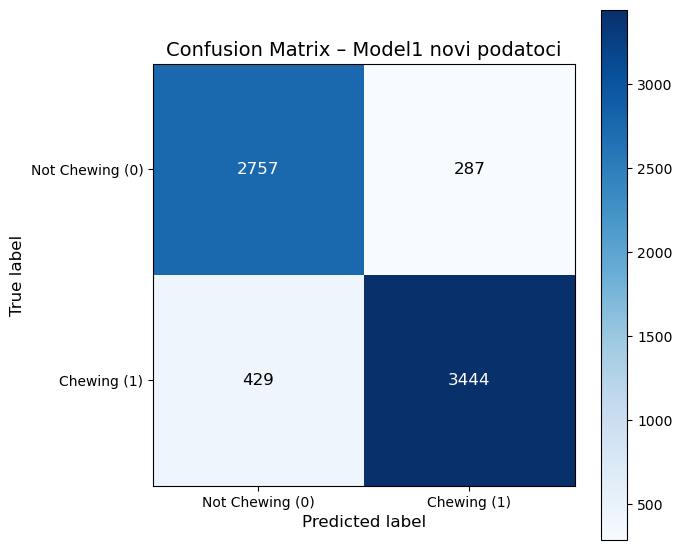

In [1]:
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([
    [2757, 287],
    [429, 3444]
])

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix – Model1 novi podatoci", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

classes = ["Not Chewing (0)", "Chewing (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import roc_curve

fpr, tpr, thr = roc_curve(y_test, y_prob)
best = thr[(tpr - fpr).argmax()]
print(best)


0.5697567


### za Transfer Learning 

In [ ]:
print("Broj features:", len(feature_cols))
for c in feature_cols:
    print(c)



Broj features: 12
Accelerometer X
Accelerometer Y
Gyroscope X
Gyroscope Y
Rotation Vector X
Rotation Vector Y
Navigation Right Temple X
Navigation Right Temple Y
Proximity Right Temple
Navigation Right Temple IQ
Navigation Right Temple Shutter
Navigation Right Temple Frame Avg


In [ ]:
OUT_DIR = r"D:\EMTEQ\novi"
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUT_DIR, "chewing_model_right.keras")
model.save(MODEL_PATH)

print("Saved model:", MODEL_PATH)


Saved model: D:\EMTEQ\novi\chewing_model_right.keras
